# Cell Morphology Classifier
**Pipeline:** Load CSVs → Filter → Batch correction → PCA → Random Forest

Run cells top to bottom. Only change the parameters in Cell 1.

In [ ]:
# ============================================================
# CELL 1 — PARAMETERS  (only edit this cell)
# ============================================================

# Folder containing your nuclei_measurements CSV files (searched recursively)
CSV_DIR = ""

# Folder where plots will be saved
OUTPUT_DIR = ""

# Minimum cells per condition to be included
# Conditions below this are dropped automatically
MIN_CELLS_PER_CONDITION = 8

# Features to use — update this list when you add new features
# v4/v5: uncomment the texture and fiber blocks when you have the new CSV
FEATURE_COLS = [
    # --- Morphology (always available) ---
    "Area_um2",
    "Equivalent_diameter_um",
    "Perimeter_um",
    "Eccentricity",
    "Solidity",
    "Orientation_rad",
    # --- Intensity (always available) ---
    "DAPI_mean_intensity",
    "DAPI_integrated_intensity"
    #"Actin_mean_intensity",
    # --- DAPI texture (available from v4 onwards) ---
    # "DAPI_contrast",
    # "DAPI_homogeneity",
    # "DAPI_energy",
    # "DAPI_correlation",
    # --- Actin texture (available from v4 onwards) ---
    # "Actin_contrast",
    # "Actin_homogeneity",
    # "Actin_energy",
    # "Actin_correlation",
    # --- Fiber features (available from v5 onwards) ---
    # "fiber_density",
    # "fiber_anisotropy",
    # "fiber_mean_angle",
    # "fiber_orientation_std",
    # "n_fibers",
]

# Random Forest
N_TREES      = 200
N_FOLDS      = 5
RANDOM_STATE = 42

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Parameters set ✓")
print(f"Using {len(FEATURE_COLS)} features")

Parameters set ✓
Using 8 features


In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

print("Imports done ✓")

Imports done ✓


In [3]:
# ============================================================
# CELL 3 — LOAD AND MERGE ALL CSV FILES
# ============================================================

csv_files = sorted(glob.glob(f"{CSV_DIR}/**/*measurements*.csv", recursive=True))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {Path(f).name}")

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {CSV_DIR}")

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    # Add replicate column from filename if not already present
    if 'Replicate' not in tmp.columns:
        tmp['Replicate'] = Path(f).stem
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print(f"\nTotal cells loaded: {len(df)}")
print("\nCells per condition:")
print(df.groupby('Condition').size().sort_values(ascending=False))
print("\nCells per replicate:")
print(df.groupby('Replicate').size())

Found 7 CSV files:
  - 241016_nuclei_measurements.csv
  - 241017_nuclei_measurements.csv
  - 241018MaxProj_nuclei_measurements.csv
  - 241110MaxProj_nuclei_measurements.csv
  - 250416_nuclei_measurements.csv
  - 250523_nuclei_measurements.csv
  - 251002_nuclei_measurements.csv

Total cells loaded: 394

Cells per condition:
Condition
DMSO      115
CytoD     113
Blebbi     50
LatA       45
Noco       35
CK666      30
NCS         4
ML1         1
Y27632      1
dtype: int64

Cells per replicate:
Replicate
241016            32
241017            25
250416            95
250523            54
251002           106
241018MaxProj     25
241110MaxProj     57
dtype: int64


In [4]:
# ============================================================
# CELL 4 — FILTER CONDITIONS WITH TOO FEW CELLS
# ============================================================

counts = df.groupby('Condition').size()
valid_conditions = counts[counts >= MIN_CELLS_PER_CONDITION].index.tolist()
dropped          = counts[counts <  MIN_CELLS_PER_CONDITION].index.tolist()

print(f"Keeping  (>= {MIN_CELLS_PER_CONDITION} cells): {valid_conditions}")
print(f"Dropping (<  {MIN_CELLS_PER_CONDITION} cells): {dropped}")

df_filtered = df[df['Condition'].isin(valid_conditions)].copy()
print(f"\nCells after filtering: {len(df_filtered)}")

# Check which features are actually present in the CSV
missing = [f for f in FEATURE_COLS if f not in df_filtered.columns]
if missing:
    print(f"\nWARNING — these features are not in the CSV yet: {missing}")
    print("Comment them out in FEATURE_COLS in Cell 1 or run the v4/v5 segmentation script first.")
    FEATURE_COLS_USED = [f for f in FEATURE_COLS if f in df_filtered.columns]
else:
    FEATURE_COLS_USED = FEATURE_COLS

print(f"\nFeatures used: {len(FEATURE_COLS_USED)}")

Keeping  (>= 8 cells): ['Blebbi', 'CK666', 'CytoD', 'DMSO', 'LatA', 'Noco']
Dropping (<  8 cells): ['ML1', 'NCS', 'Y27632']

Cells after filtering: 388

Features used: 8


In [5]:
# Pool LatA + CytoD into AcDep, keep only DMSO vs AcDep
df_filtered['Condition'] = df_filtered['Condition'].replace({
    'LatA':  'AcDep',
    'CytoD': 'AcDep'
})

df_filtered = df_filtered[df_filtered['Condition'].isin(['DMSO', 'AcDep'])].copy()

print("Conditions after pooling:")
print(df_filtered.groupby('Condition').size())

Conditions after pooling:
Condition
AcDep    158
DMSO     115
dtype: int64


Condition x Replicate table:
Condition      AcDep  DMSO
Replicate                 
241016            10    13
241017            15     4
250416            34    20
250523             0    15
251002            67    39
241018MaxProj     15     4
241110MaxProj     17    20


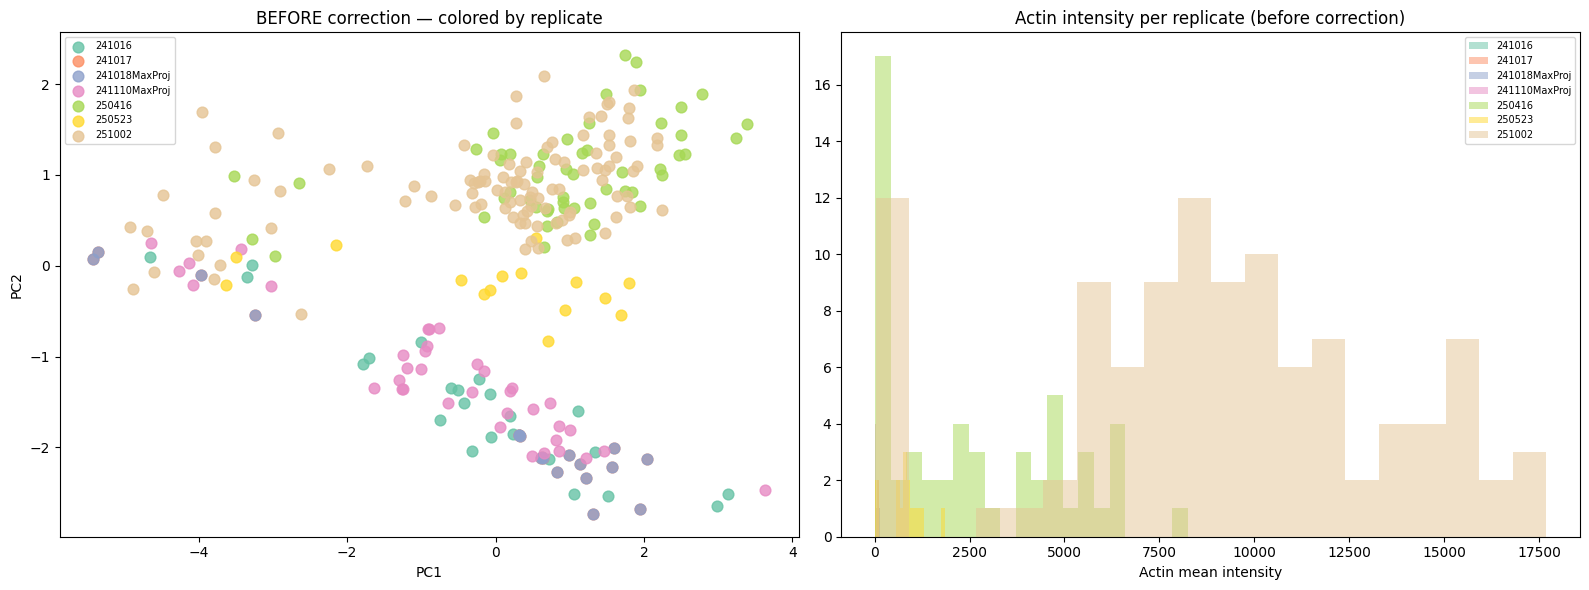

In [6]:
# ============================================================
# CELL 5 — BATCH EFFECT DIAGNOSIS
# ============================================================

print("Condition x Replicate table:")
pivot = df_filtered.groupby(['Replicate', 'Condition']).size().unstack(fill_value=0)
print(pivot)

# Quick PCA colored by replicate to visualize batch effect
from sklearn.preprocessing import StandardScaler
X_raw = df_filtered[FEATURE_COLS_USED].values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

pca_diag = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_diag = pca_diag.fit_transform(X_raw_scaled)

unique_reps = df_filtered['Replicate'].unique()
palette_rep = sns.color_palette("Set2", len(unique_reps))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — by replicate
for i, rep in enumerate(unique_reps):
    mask = df_filtered['Replicate'] == rep
    axes[0].scatter(X_pca_diag[mask, 0], X_pca_diag[mask, 1],
                    label=rep, color=palette_rep[i], s=60, alpha=0.8)
axes[0].set_title("BEFORE correction — colored by replicate")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7)

# Right — actin intensity histograms per replicate
for i, rep in enumerate(unique_reps):
    mask = df_filtered['Replicate'] == rep
    axes[1].hist(df_filtered[mask]['Actin_mean_intensity'],
                 bins=20, alpha=0.5, label=rep, color=palette_rep[i])
axes[1].set_title("Actin intensity per replicate (before correction)")
axes[1].set_xlabel("Actin mean intensity")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/batch_diagnosis.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 6 — BATCH CORRECTION (DMSO-anchored z-score)
# ============================================================
# For each replicate:
#   1. Compute mean and std of DMSO cells (the control anchor)
#   2. Subtract mean, divide by std for ALL cells in that replicate
# Result: drug effects expressed as deviations from DMSO baseline

df_corrected = df_filtered.copy()

for replicate in df_filtered['Replicate'].unique():
    dmso_mask = (
        (df_filtered['Replicate'] == replicate) &
        (df_filtered['Condition'] == 'DMSO')
    )

    if dmso_mask.sum() == 0:
        print(f"WARNING: No DMSO cells in replicate {replicate} — skipping correction for this replicate")
        continue

    dmso_cells = df_filtered[dmso_mask][FEATURE_COLS_USED]
    dmso_mean  = dmso_cells.mean()
    dmso_std   = dmso_cells.std()
    dmso_std[dmso_std < 1e-8] = 1.0  # avoid division by zero

    rep_mask = df_filtered['Replicate'] == replicate
    df_corrected.loc[rep_mask, FEATURE_COLS_USED] = (
        (df_filtered.loc[rep_mask, FEATURE_COLS_USED] - dmso_mean) / dmso_std
    )

print("Batch correction applied ✓")
print("\nDMSO cells used as reference per replicate:")
print(df_filtered[df_filtered['Condition'] == 'DMSO'].groupby('Replicate').size())

Batch correction applied ✓

DMSO cells used as reference per replicate:
Replicate
241016           13
241017            4
250416           20
250523           15
251002           39
241018MaxProj     4
241110MaxProj    20
dtype: int64


In [8]:
# ============================================================
# CELL 7 — PREPARE FEATURE MATRIX
# ============================================================

X = df_corrected[FEATURE_COLS_USED].values
y = df_corrected['Condition'].values

le = LabelEncoder()
y_encoded  = le.fit_transform(y)
class_names = le.classes_

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Color palette — one color per condition, reused in all plots
palette   = sns.color_palette("tab10", len(class_names))
color_map = {cond: palette[i] for i, cond in enumerate(class_names)}

print(f"Feature matrix: {X_scaled.shape}")
print(f"Classes: {class_names}")

Feature matrix: (273, 8)
Classes: ['AcDep' 'DMSO']


PCA explained variance: PC1=56.6%, PC2=14.1%


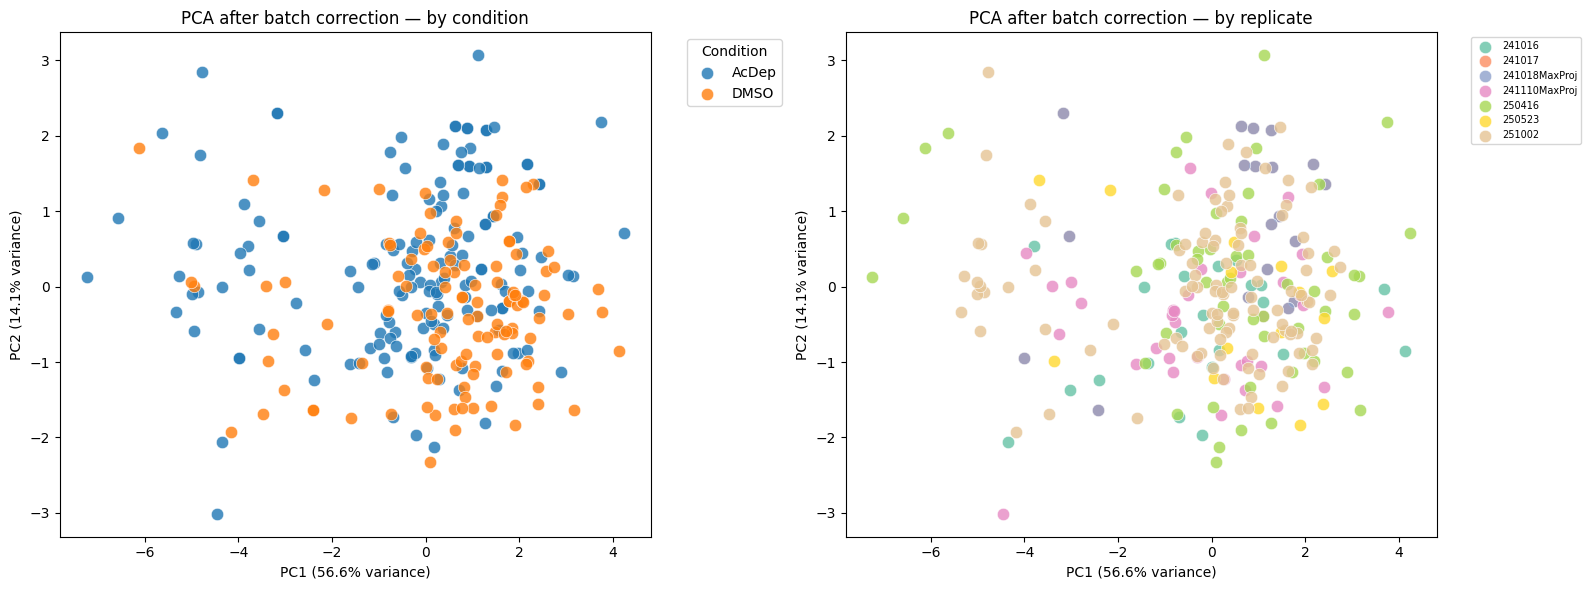

PCA saved ✓


In [9]:
# ============================================================
# CELL 8 — PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

print(f"PCA explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — by condition
for cond in class_names:
    mask = df_corrected['Condition'] == cond
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=cond, color=color_map[cond],
                    s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[0].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[0].set_title("PCA after batch correction — by condition")
axes[0].legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')

# Right — by replicate (sanity check: should be well mixed after correction)
unique_reps = df_corrected['Replicate'].unique()
palette_rep = sns.color_palette("Set2", len(unique_reps))
for i, rep in enumerate(unique_reps):
    mask = df_corrected['Replicate'] == rep
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=rep, color=palette_rep[i],
                    s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[1].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[1].set_title("PCA after batch correction — by replicate")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_corrected.png", dpi=150, bbox_inches='tight')
plt.show()
print("PCA saved ✓")

PCA loadings (which features drive separation):
                             PC1    PC2
Equivalent_diameter_um     0.457 -0.066
Area_um2                   0.454 -0.081
Perimeter_um               0.450 -0.110
DAPI_integrated_intensity  0.447 -0.029
DAPI_mean_intensity        0.293 -0.015
Solidity                   0.292  0.152
Eccentricity              -0.101 -0.669
Orientation_rad            0.031  0.711


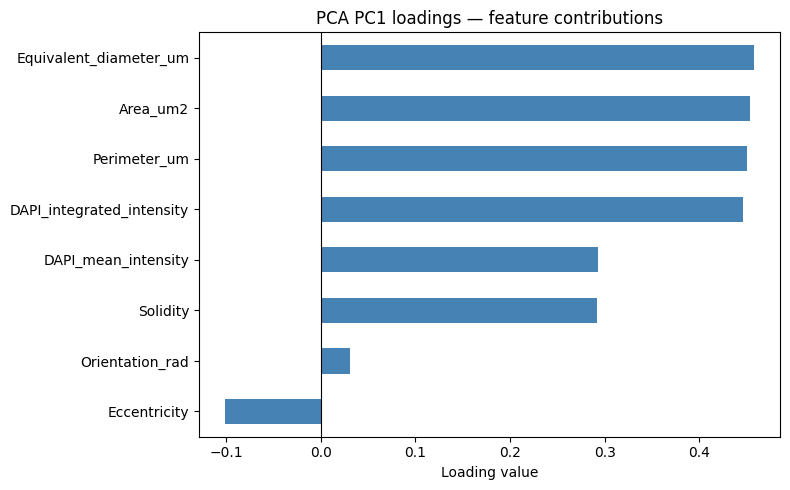

In [10]:
# ============================================================
# CELL 9 — PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS_USED,
    columns=['PC1', 'PC2']
).sort_values('PC1', key=abs, ascending=False)

print("PCA loadings (which features drive separation):")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("PCA PC1 loadings — feature contributions")
ax.set_xlabel("Loading value")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_loadings.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# CELL 10 — RANDOM FOREST CLASSIFIER
# ============================================================

rf = RandomForestClassifier(
    n_estimators=N_TREES,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Running {N_FOLDS}-fold stratified cross-validation...")
y_pred = cross_val_predict(rf, X_scaled, y_encoded, cv=cv)

y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = le.inverse_transform(y_encoded)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_labels, y_pred_labels))

Running 5-fold stratified cross-validation...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       AcDep       0.69      0.78      0.73       158
        DMSO       0.63      0.51      0.57       115

    accuracy                           0.67       273
   macro avg       0.66      0.65      0.65       273
weighted avg       0.67      0.67      0.66       273



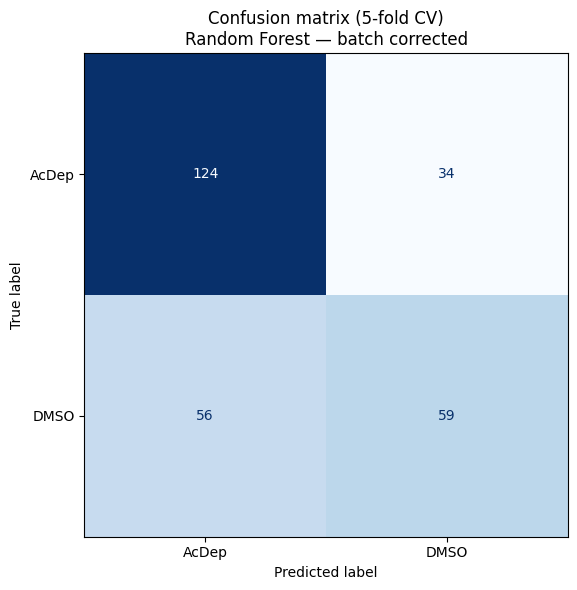

Confusion matrix saved ✓


In [12]:
# ============================================================
# CELL 11 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"Confusion matrix ({N_FOLDS}-fold CV)\nRandom Forest — batch corrected")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓")

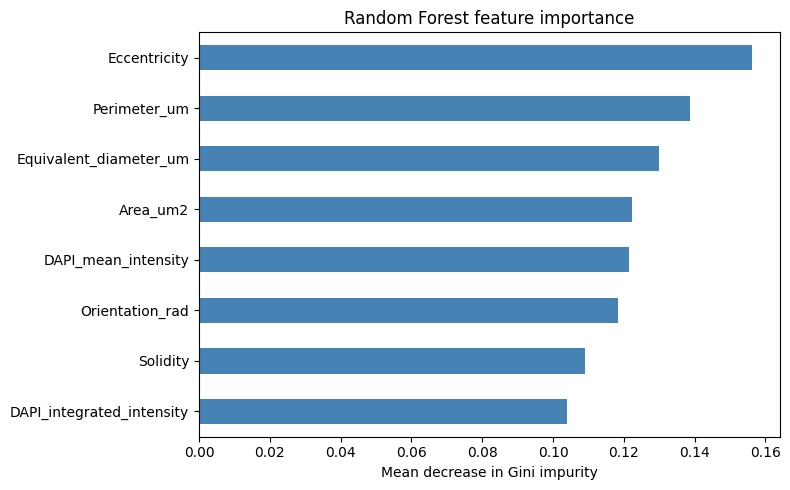


=== TOP 5 MOST IMPORTANT FEATURES ===
Eccentricity              0.1563
Perimeter_um              0.1388
Equivalent_diameter_um    0.1300
Area_um2                  0.1222
DAPI_mean_intensity       0.1214
dtype: float64


In [13]:
# ============================================================
# CELL 12 — FEATURE IMPORTANCE
# ============================================================

# Fit on full dataset to get stable importances
rf.fit(X_scaled, y_encoded)
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS_USED)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(5, len(FEATURE_COLS_USED) * 0.4)))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Mean decrease in Gini impurity")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 5 MOST IMPORTANT FEATURES ===")
print(importances.sort_values(ascending=False).head(5).round(4))